<div align="center">
    <h1>Graver Augmentation Multiseed Algorithm
    </h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/AzAINN">Azain Khalid</a>
    <br>
    <i>Department of Computer Science, Purdue University</i>
    <br>
    <i> Undergraduate Researcher</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/QuIP/blob/main/notebooks_jl/3-GAMA.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

**Environment setup**

For local execution from the repository root, run `uv sync --group qubo` and `make setup-julia NOTEBOOK=notebooks_jl/3-GAMA.ipynb` before launching Jupyter. This notebook reuses the repo-local Python environment for the D-Wave Ocean stack instead of relying on Julia's `CondaPkg` resolver.

This notebook should open directly with the **Julia** runtime in Google Colab. If it does not, switch the runtime before running the next cell.
The setup cell will clone `SECQUOIA/QuIP` into the Colab workspace when needed, activate `notebooks_jl/envs/3-GAMA/Project.toml`, install the Python D-Wave Ocean packages into the Colab Python runtime, and print progress for clone, activate, instantiate, and package-load steps. Package precompilation still happens as needed during setup. The first Colab run can still take several minutes.


In [1]:
function load_notebook_bootstrap()
    candidates = (
        joinpath(pwd(), "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "..", "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "QuIP", "scripts", "notebook_bootstrap.jl"),
        joinpath("/content", "QuIP", "scripts", "notebook_bootstrap.jl"),
    )

    for candidate in candidates
        if isfile(candidate)
            include(candidate)
            return nothing
        end
    end

    in_colab = haskey(ENV, "COLAB_RELEASE_TAG") || haskey(ENV, "COLAB_JUPYTER_IP") || isdir(joinpath("/content", "sample_data"))
    if in_colab
        repo_dir = get(ENV, "QUIP_REPO_DIR", joinpath(pwd(), "QuIP"))
        if !isdir(repo_dir)
            println("[bootstrap] Cloning SECQUOIA/QuIP into $repo_dir")
            run(`git clone --depth 1 https://github.com/SECQUOIA/QuIP.git $repo_dir`)
        end
        include(joinpath(repo_dir, "scripts", "notebook_bootstrap.jl"))
        return nothing
    end

    error("Could not locate scripts/notebook_bootstrap.jl from $(pwd()).")
end

load_notebook_bootstrap()

BOOTSTRAP = QuIPNotebookBootstrap.bootstrap_notebook("3-GAMA")

QUIP_REPO_DIR = BOOTSTRAP.repo_dir
JULIA_NOTEBOOKS_DIR = BOOTSTRAP.notebooks_dir
JULIA_PROJECT_DIR = BOOTSTRAP.project_dir
IN_COLAB = BOOTSTRAP.in_colab


[14:11:15] Notebook project key: 3-GAMA


[14:11:15] Google Colab runtime detected: false


[14:11:15] Using Python runtime: /home/bernalde/repos/QuIP/.venv/bin/python3


[14:11:15] Activating project at `/home/bernalde/repos/QuIP/notebooks_jl/envs/3-GAMA`


  Activating project at `~/repos/QuIP/notebooks_jl/envs/3-GAMA`


[14:11:15] Instantiating Julia packages


  1.002893 seconds (1.02 M allocations: 97.466 MiB, 3.40% gc time, 27.53% compilation time: 58% of which was recompilation)
[14:11:16] Loading notebook packages


[14:11:25] Working directory set to /home/bernalde/repos/QuIP/notebooks_jl


[14:11:25] Notebook bootstrap complete


false

## Graver Augmentation Multiseed Algorithm (Julia)

### Introduction to GAMA

The Graver Augmentation Multiseed Algorithm (GAMA) was proposed by Alghassi, Dridi, and Tayur in the works listed in [Reference [1]](#reference-1) and [Reference [2]](#reference-2).
The three main ingredients of this algorithm, designed to solve integer programs with linear constraints and nonlinear objective, are:

- Computing the Graver basis (or a subset of it) of an integer program.
- Performing an augmentation.
- Given that only for certain objective functions, the Graver augmentation is guaranteed to find a globally optimal solution, the algorithm is initialized in several points.

This algorithm can be adapted to take advantage of Quantum Computers by leveraging them as black-box Ising/QUBO problem solvers.
In particular, obtaining several feasible solution points for the augmentation and computing the kernel of the constraint matrix can be posed as QUBO problems.
After obtaining these solutions, other routines implemented in classical computers are used to solve the optimization problems, making this a hybrid quantum-classical algorithm.

### Introduction to Graver basis computation

This notebook makes simple computations of Graver basis. Because of the complexity of these computations, we suggest that for more complicated problems you install the excellent **[4ti2](https://4ti2.github.io/)** software, an open-source implementation of several routines useful for the study of integer programming through algebraic geometry. It can be used as a stand-alone library and called from C++ or directly from Julia. In Julia, a binding is provided by **[lib4ti2_jll](https://github.com/JuliaBinaryWrappers/lib4ti2_jll.jl)**.

A Graver basis is defined as

$$
\mathcal{G}(\mathbf{A}) = \bigcup_{j} \mathcal{H}_{j}(\mathbf{A})
$$

where $\mathcal{H}_{j}(\mathbf{A})$ are the minimal Hilbert basis of $\mathbf{A}$ in each orthant.

Equivalently we can define the Graver basis as the $\sqsubseteq$-minimal set of a lattice

$$
\mathcal{L}(\mathbf{A}) = \left\lbrace{}{\mathbf{x} : \mathbf{A} \mathbf{x} = 0, \mathbf{x} \in \mathbb{Z}^{n}}\right\rbrace{} \setminus \left\lbrace{}{0}\right\rbrace{} = \ker A \cap \mathbb{Z}^{n}
$$

where the partial ordering $\mathbf{x} \sqsubseteq \mathbf{y}$ holds whenever $x_i y_i \geq 0$ and $\left\vert x_i \right\vert \leq \left\vert y_i \right\vert$ for all $i$.

Here we won't interact with the Quantum Computer. However, we will obtain the Graver basis of a problem using package 4ti2. This notebook studies the behavior of the search algorithm in the case that we only have available a subset of the Graver basis.


## Problem statement

We will be solving EXAMPLE 4 in the code, which corresponds to Case 2 in the original GAMA paper.
The problem is derived from finance and deals with the maximization of expected returns on investments and the minimization of the variance.

$$
\begin{array}{rll}
    \displaystyle \min & \displaystyle -\sum_{i = 1}^{n} \mu_{i} x_{i} + \sqrt{\frac{1 - \varepsilon}{\varepsilon} \sum_{i = 1}^{n} \sigma_{i}^2 x_{i}^2 } \\
    \textrm{s.t.}      & A \mathbf{x} = \mathbf{b} \\
    ~                  & \mathbf{x} \in \left\lbrace{}{-2, -1, 0, 1, 2}\right\rbrace{}^{n}
\end{array}
$$

In [2]:
f(x) = μ'x + sqrt(((1-ε)/ε) * (σ .^ 2)' * (x .^ 2))

f (generic function with 1 method)

### Example

Let

$$
A = \begin{bmatrix}
1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 0 & 1 & 0 & 1 & 0 \\\n1 & 1 & 1 & 1 & 0 & 1 & 0 & 1 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1 & 1 \\\n0 & 1 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 0 & 0 & 1 & 0 & 0 & 1 & 1 & 1 \\\n0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\\n0 & 1 & 1 & 1 & 1 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 1 & 0 \\\n\end{bmatrix}
$$

This particular instance of convex INLP has $m = 5$, $n = 25$, $\varepsilon = 0.01$, $\mu_{i} = \textrm{rand}[0, 1]$, $\sigma_{i} = \textrm{rand}[0, \mu_{i}]$.
$A \in \mathbb{B}^{m \times n}$ and each $b_{j}$ is half the sum of the $j$-th row of $A$.
In this example, $\mathbf{b} = \left({9, 8, 7, 5, 5}\right)'$.

The Graver basis of this matrix $A$ has 29789 elements, which on a standard laptop using 4ti2 takes about 5 seconds to compute. With `lib4ti2_jll` available, the notebook can compute that basis directly in Colab or locally; the bundled `graver.npy` file is only a fallback when the `graver` binary is unavailable.


First we would write this problem as an unconstrained one by penalizing the linear constraints as quadratics in the objective.
Let's first define the problem parameters.


In [3]:
A = [
    1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 1 0 1 0
    1 1 1 1 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 1 1
    0 1 0 0 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 1 0 0 1 1 1
    0 0 0 0 0 0 0 1 0 1 1 1 0 1 1 1 1 0 0 1 0 0 0 0 0
    0 1 1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0
]

m, n = size(A)

b = vec(ceil.(Int, sum(A; dims = 2) / 2));

In [4]:
x0 = [1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, -2, 1, 0, -1, 0, 1, -1, 1, -2, -2, 1, 1, 1]

xl = fill(-2, n)
xu = fill( 2, n);

In [5]:
ε = 0.01
μ = rand(n)       # ~ [0, 1]
σ = rand(n) .* μ; # ~ [0, μ]

In [6]:
using DelimitedFiles
import lib4ti2_jll
import BinaryWrappers
using NPZ


In [7]:
const lib4ti2_bin = BinaryWrappers.@generate_wrappers(lib4ti2_jll)

"""Return `true` when the bundled 4ti2 `graver` executable is available."""
function has_graver()::Bool
    try
        return success(`$(lib4ti2_bin)/graver --help`)
    catch
        return false
    end
end

"""Print the help text for the bundled 4ti2 `graver` executable."""
function graver()
    run(`$(lib4ti2_bin)/graver --help`)

    return nothing
end

"""Run the bundled 4ti2 `graver` executable on the given project path."""
function graver(proj_path::AbstractString; silent::Bool = true)
    if silent
        run(`$(lib4ti2_bin)/graver -q $(proj_path)`)
    else
        run(`$(lib4ti2_bin)/graver $(proj_path)`)
    end

    return nothing
end

"""Write an integer matrix in the text format expected by 4ti2."""
function write_mat(path::AbstractString, A)
    m, n = size(A)

    open(path, "w") do io
        println(io, "$m $n")

        join(io, (join(@view(A[i, :]), " ") for i = 1:m), "\n")
    end

    return nothing
end

"""Read a matrix written in 4ti2's plain-text format."""
function read_mat(path::AbstractString, type = Int)
    m, n = parse.(Int, split(readline(path)))

    A = Matrix{type}(undef, m, n)

    open(path, "r") do io
        readline(io)

        for (i, line) in enumerate(eachline(io))
            A[i, :] .= parse.(Int, split(line))
        end
    end

    return A
end

"""
Return the Graver basis of `A` by calling the bundled 4ti2 `graver` executable.

Only the constraint matrix is written because the Graver basis depends on `A` alone;
the box bounds `xl` and `xu` are enforced later during augmentation.
"""
function compute_graver_basis_local(A)
    G = nothing

    mktempdir() do path
        proj_path = joinpath(path, "proj")

        write_mat("$(proj_path).mat", A)
        graver(proj_path)

        G = read_mat("$(proj_path).gra")
    end

    return G
end

"""Load the bundled `graver.npy` file when the 4ti2 executable is unavailable."""
function download_graver_basis()
    npy_path = joinpath(JULIA_NOTEBOOKS_DIR, "graver.npy")
    G = NPZ.npyread(npy_path)
    return Array{Int}(G)
end

"""Return the Graver basis of `A`, preferring the bundled 4ti2 binary when available."""
function graver_basis(A)
    if has_graver()
        return compute_graver_basis_local(A)
    else
        return download_graver_basis()
    end
end


graver_basis

In [8]:
G = graver_basis(A)

29789×25 Matrix{Int64}:
 0  0   0   0   0   0  1  0  0   0  …   0   0  0  0  -1  0   0  0  0  0  0
 1  0   0   0   0   0  0  0  0   0      0   0  0  0  -1  0  -1  0  0  0  0
 0  0   0   0   0   0  0  0  1   0      0   0  0  0  -1  0   0  0  0  0  0
 0  0   0   0   0   0  0  0  0   0      0   0  0  1  -1  0  -1  0  0  0  0
 0  1  -1   0   0   0  0  0  0   0      0   0  0  0   0  0   0  0  0  0  0
 0  1   0  -1   0   0  0  0  0   0  …   0   0  0  0   0  0   0  0  0  0  0
 0  1   0   0  -1   0  0  0  0   0      0   0  0  0   0  0  -1  0  0  0  0
 0  1   0   0   0  -1  0  0  0   0      0   0  0  0   0  0   0  0  0  0  0
 0  1   0   0   0   0  0  1  0  -1      0   0  0  0  -1  0  -2  0  0  0  0
 0  0   0   0   0   0  0  1  0   0      0   0  0  0  -1  0   0  0  0  0  0
 0  0   0   0   0   0  0  1  0   0  …   0   0  0  0   0  0  -1  0  0  0  0
 0  1   0   0   0   0  0  1  0   0      0   0  0  0  -1  0  -2  0  0  0  0
 0  0   0   0   0   0  0  1  0   0     -1   0  0  0  -1  0   0  0  0  0  0
 

In [9]:
# Define rules to choose augmentation element, either the best one (argmin) or the first one that is found
function argmin_rule(a)
    local i, y, α = (nothing, NaN, Inf)

    for (_i, (_y, _α)) in enumerate(a)
        if _α < α
            i, y, α = (_i, _y, _α)
        end
    end

    return (i, (y, α))
end

function greedy_rule(a)
    local i, y, α = (nothing, NaN, Inf)

    for (_i, (_y, _α)) in enumerate(a)
        if _α ≉ 0.0
            return (_i, (_y, _α))
        else
            i, y, α = (_i, _y, _α)
        end
    end

    return (i, (y, α))
end

greedy_rule (generic function with 1 method)

In [10]:
# Bisection rules for finding best step size
"""Compute the best integer step size along a Graver direction within the box bounds."""
function bisection_rule(f::Function, g, x, xl = nothing, xu = nothing, laststep = nothing)
    if g == laststep
        return (f(x), 0)
    end

    if xl === nothing
        xl = zeros(length(x))
    end

    if xu === nothing
        xu = fill(2 * maximum(x), length(x))
    end

    u = maximum(xu) - minimum(xl)
    l = -u

    for (i, gi) in enumerate(g)
        if gi >= 1
            u = min(u, floor(Int, (xu[i] - x[i]) / gi))
            l = max(l, ceil(Int, (xl[i] - x[i]) / gi))
        elseif gi <= -1
            u = min(u, floor(Int, (xl[i] - x[i]) / gi))
            l = max(l, ceil(Int, (xu[i] - x[i]) / gi))
        end
    end

    α = u

    while u - l > 1
        α = ifelse(f(x + l * g) < f(x + u * g), l, u)

        p1 = floor(Int, (l + u) / 2) - 1
        p2 = floor(Int, (l + u) / 2)
        p3 = floor(Int, (l + u) / 2) + 1

        if f(x + p1 * g) < f(x + p2 * g)
            u = floor(Int, (l + u) / 2)
        elseif f(x + p3 * g) < f(x + p2 * g)
            l = floor(Int, (l + u) / 2) + 1
        else
            α = p2
            break
        end
    end

    if f(x + l * g) < f(x + u * g) && f(x + l * g) < f(x + α * g)
        α = l
    elseif f(x + u * g) < f(x + α * g)
        α = u
    end

    return (f(x + α * g), α)
end

# We can just have a single step move (works well with greedy approach)
"""Evaluate whether a single forward or backward step improves the objective."""
function single_move_rule(f::Function, g, x, xl = nothing, xu = nothing, laststep = nothing)
    if xl === nothing
        xl = zeros(length(x))
    end

    if xu === nothing
        xu = fill(2 * maximum(x), length(x))
    end

    α = 0

    if all(x + g .<= xu) && all(x + g .>= xl)
        if f(x + g) < f(x)
            α = 1
        end
    elseif all(x - g .<= xu) && all(x - g .>= xl)
        if f(x - g) < f(x) && f(x - g) < f(x + g)
            α = -1
        end
    end

    return (f(x + α * g), α)
end


single_move_rule

In [11]:
"""Compute the Graver basis for `A` and run the augmentation experiment from `x0`."""
function augmentation(
    f::Function,
    A,
    b,
    x0,
    xl,
    xu;
    silent::Bool = true,
    max_iter::Integer = 1_000,
    step_rule::Function = bisection_rule,
    choice_rule::Function = argmin_rule,
)
    G = graver_basis(A)

    return augmentation(
        f,
        G,
        A,
        b,
        x0,
        xl,
        xu;
        silent,
        max_iter,
        step_rule,
        choice_rule,
    )
end

"""Apply the selected augmentation rule to a fixed Graver basis until convergence."""
function augmentation(
    f::Function,
    G,
    A,
    b,
    x0,
    xl,
    xu;
    silent::Bool = true,
    max_iter::Integer = 1_000,
    step_rule::Function = bisection_rule,
    choice_rule::Function = argmin_rule,
)
    # Constraints definition
    isfeasible = (x) -> (A * x == b)

    Δ = 1
    n = length(x0)
    k = 1

    if !silent
        println("Initial point: $(x0)")
        println("Objective function: $(f(x0))")
    end

    y = nothing
    x = copy(x0)
    δ = Vector{Int}(undef, n)
    gprev = Vector{Int}(undef, n)

    while Δ != 0 && k < max_iter
        i, (y, Δ) = choice_rule((step_rule(f, g, x, xl, xu, gprev) for g in eachrow(G)))

        δ .= @view(G[i, :]) .* Δ
        x .+= δ
        gprev .= @view(G[i, :])

        if !silent
            println("Iteration ", k)
            println(i, (y, Δ))
            println("Augmentation direction:", gprev)
            println("Distanced moved:", Δ)
            println("Step taken:", δ)
            println("Objective function:", y)
            println(f(x))
            println("Current point:", x)
            println("Are constraints satisfied?", isfeasible(x))
        end

        k += 1
    end

    return (k, y, x)
end


augmentation

First, we will compare our augmentation strategies, either best or greedy, and for that last case, either computing the best step or a single move.
In the order that was mentioned, the augmentation will take more iterations, but each one of the augmentation steps or iterations is going to be cheaper.



In [12]:
println("Best-augmentation: Choosing among the best step that each element of G can do (via bisection), the one that reduces the most the objective")

iter, f_obj, xf = @time augmentation(
    f, G, A, b, x0, xl, xu;
    step_rule = bisection_rule, choice_rule = argmin_rule
)

println("$(iter), iterations")
println("solution: $(xf)")
println("objective: $(f_obj)")

println("Greedy-best-augmentation: Choosing among the best step that each element of G can do (via bisection), the first one encountered that reduces the objective")

iter,f_obj,xf = @time augmentation(
    f, G, A, b, x0, xl, xu;
    step_rule = bisection_rule, choice_rule = greedy_rule,
)

println("$(iter), iterations")
println("solution: $(xf)")
println("objective: $(f_obj)")

println("Greedy-augmentation: Choosing among the first element of G that with a single step reduces the objective")

iter,f_obj,xf = @time augmentation(
    f, G, A, b, x0, xl, xu;
    step_rule = single_move_rule, choice_rule = greedy_rule,
)

println("$(iter), iterations")
println("solution: $(xf)")
println("objective: $(f_obj)")

Best-augmentation: Choosing among the best step that each element of G can do (via bisection), the one that reduces the most the objective
  4.723868 seconds (57.59 M allocations: 3.170 GiB, 7.25% gc time, 13.60% compilation time)
14, iterations


solution: [-2, -1, -1, 0, 0, 1, 0, 2, 0, 1, 0, 2, 0, 0, -1, 1, -2, 1, 0, 2, 2, 2, 0, 1, 2]
objective: 15.381176262453856
Greedy-best-augmentation: Choosing among the best step that each element of G can do (via bisection), the first one encountered that reduces the objective
  0.550235 seconds (5.49 M allocations: 308.811 MiB, 9.60% gc time, 23.83% compilation time)


30, iterations
solution: [0, 0, 1, 0, 0, 0, 0, 2, 0, 1, 0, 2, 0, 0, -1, 0, -1, 0, 0, 2, 0, 1, 1, 0, 2]
objective: 7.393834781256107
Greedy-augmentation: Choosing among the first element of G that with a single step reduces the objective
  0.616620 seconds (3.03 M allocations: 158.812 MiB, 4.03% gc time, 71.65% compilation time)
28, iterations


solution: [0, 0, 1, 1, 0, 0, 0, 2, 0, 1, 0, 2, 0, 0, -1, 0, -1, 0, 0, 2, 0, 0, 1, 0, 2]
objective: 7.8455994307533405


Now we can highlight another feature of the algorithm, computing starting feasible solutions. For this case we formulate a QUBO and solve it via annealing.
In this particular case, we will not encode the integer variables and will only look for feasible solutions with $x \in \{0,1\}^n$.


### QUBO formulation for feasible starting points

We now formulate a QUBO to generate diverse feasible starting points for the augmentation stage. In this part of the notebook, we only search over binary points with $x \in \{0,1\}^n$ before passing those feasible candidates to the classical augmentation routine.

To do that, we minimize the squared residual of the linear constraints over binary points:

$$
\min_{x \in \{0,1\}^n} \|Ax - b\|_2^2 = \min_{x \in \{0,1\}^n} x^\top A^\top A x - 2 b^\top A x + b^\top b.
$$

The constant term $b^\top b$ does not affect the minimizers, so the notebook keeps it as an offset while the binary quadratic model is built from `Q = A^\top A - 2 \operatorname{diag}(A^\top b)`. Any sample with objective value `0` is therefore a feasible starting point for the augmentation stage.


We use simulated annealing here because the goal is not a single feasible point but a diverse set of feasible starts. A MIP solver would typically stop after one optimum, while annealing can return several distinct zero-energy states of the same QUBO in one run.


In [13]:
if !@isdefined(JuMP)
    using JuMP
end

if !@isdefined(DWave)
    using DWave
end

if !@isdefined(LinearAlgebra)
    using LinearAlgebra
end


In [14]:
"""Sample binary feasible starting points by minimizing the QUBO residual."""
function get_feasible(A, b; num_reads = 1_000)
    m, n = size(A)

    Q = A' * A - 2 * diagm(A' * b)
    β = b' * b

    # Define Binary Quadratic Model using new DWave.jl
    model = Model(DWave.Neal.Optimizer)

    @variable(model, x[1:n], Bin)

    @objective(model, Min, x' * Q * x + β)

    set_optimizer_attribute(model, "num_reads", num_reads)

    optimize!(model)

    X = [
        round.(Int, value.(x; result = i))
        for i = 1:result_count(model)
        if objective_value(model; result = i) ≈ 0.0
    ]

    println("$(length(X)) feasible solutions found.")

    return X
end


get_feasible

In [15]:
X_feas = get_feasible(A,b; num_reads = 20);

20 feasible solutions found.


We take 20 samples using simulated annealing and notice that most of them are feasible and different. Let's now apply the augmentation procedure to each one of them and record the final objective and the number of iterations it takes. Here we will use the 3rd augmentation strategy (Greedy) because of runtime.


In [16]:
"""Run the full-basis augmentation experiment for each feasible starting point in `X`."""
function augmentation_experiment(f, G, A, b, X, xl, xu)
    K = length(X)

    Y = Vector{Float64}(undef, K)
    I = Vector{Int}(undef, K)
    T = Vector{Float64}(undef, K)

    for (i, x) in enumerate(X)
        result = @timed augmentation(
            f, G, A, b, x, xl, xu;
            step_rule   = single_move_rule,
            choice_rule = greedy_rule,
        )

        num_iter, obj_val, _ = result.value

        Y[i] = obj_val
        I[i] = num_iter
        T[i] = result.time
    end

    return (Y, I, T)
end

Y_feas = f.(X_feas)

Y_aug, I_aug, T_aug = augmentation_experiment(f, G, A, b, X_feas, xl, xu);


We record the initial objective function, the one after doing the augmentation, and the number of augmentation steps.

In [17]:
if !@isdefined(Measures)
    using Measures
end

if !@isdefined(Random)
    using Random
end

if !@isdefined(Plots)
    using Plots
end

if !@isdefined(StatsBase)
    using StatsBase
end

if !@isdefined(StatsPlots)
    using StatsPlots
end


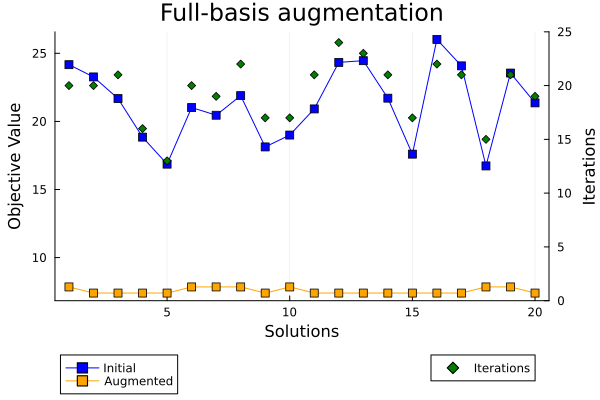

In [18]:
"""Plot the initial and augmented objectives together with the iteration counts."""
function plot_augmentation(Y_feas, Y_aug, I_aug; experiment_name = "Augmentation")
    plt = plot(;
        plot_title = experiment_name,
        bottom_margin = 15mm,
    )

    plot!(
        plt, Y_feas;
        label       = "Initial",
        color       = :blue,
        markershape = :square,
    )
    plot!(
        plt, Y_aug;
        label       = "Augmented",
        color       = :orange,
        markershape = :square,
        ylabel      = "Objective Value",
        xlabel      = "Solutions",
        legend      = (0.1, -0.25),
    )

    scatter!(
        twinx(plt), I_aug;
        label       = "Iterations",
        color       = :green,
        legend      = (0.85, -0.25),
        markershape = :diamond,
        ylabel      = "Iterations",
        ylims       = (0, maximum(I_aug) + 1),
    )

    return plt
end

plot_augmentation(Y_feas, Y_aug, I_aug; experiment_name = "Full-basis augmentation")


With the complete Graver basis, every starting point improves substantially, but the final objective values can still differ. In this notebook we use the greedy single-move augmentation rule on a nonseparable convex objective, so different feasible starts can terminate at different local optima even with the full basis.

Now let's try an extreme case, where we only have 10 of the elements of the Graver basis.


In [19]:
"""Run the augmentation experiment on a random subset of the Graver basis."""
function partial_augmentation_experiment(f, G, A, b, X, xl, xu; seed = nothing, num_samples = 10)
    K = length(X)

    Y = Vector{Float64}(undef, K)
    I = Vector{Int}(undef, K)
    T = Vector{Float64}(undef, K)

    index = sample(1:size(G, 1), num_samples, replace = false)
    G_idx = G[index, :]

    for (i, x) in enumerate(X)
        result = @timed augmentation(
            f, G_idx, A, b, x, xl, xu;
            step_rule   = single_move_rule,
            choice_rule = greedy_rule,
        )

        num_iter, obj_val, _ = result.value

        Y[i] = obj_val
        I[i] = num_iter
        T[i] = result.time
    end

    return (Y, I, T)
end

Y_feas = f.(X_feas)

Y_paug, I_paug, T_paug = partial_augmentation_experiment(f, G, A, b, X_feas, xl, xu);


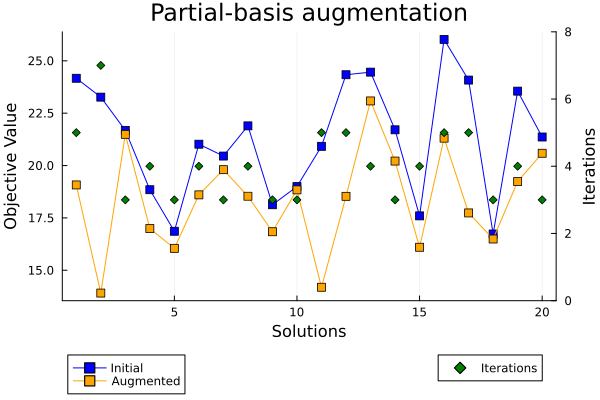

In [20]:
plot_augmentation(Y_feas, Y_paug, I_paug; experiment_name = "Partial-basis augmentation")


Here we can barely improve the objective and can only perform a few iterations before we cannot improve the solution.
But if we compare the runtimes in both cases, we find that...

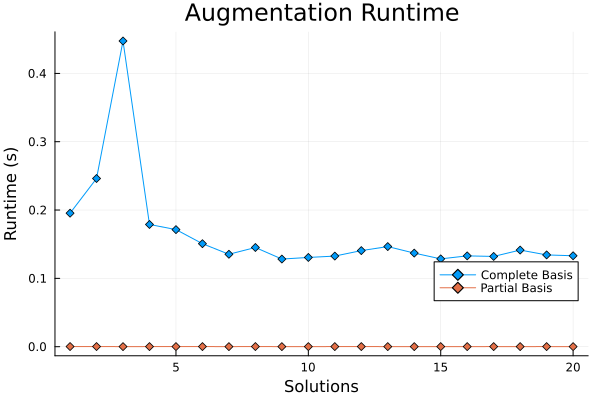

In [21]:
"""Plot the runtime comparison between the full and partial augmentation experiments."""
function plot_augmentation_runtime(T_aug, T_paug)
    plt = plot(;
        plot_title = "Augmentation Runtime",
        xlabel     = "Solutions",
        ylabel     = "Runtime (s)",
        legend     = (0.8, 0.25),
    )

    plot!(T_aug; label = "Complete Basis", markershape = :diamond)
    plot!(T_paug; label = "Partial Basis", markershape = :diamond)

    return plt
end

plot_augmentation_runtime(T_aug, T_paug)


...the time to do augmentation only having 10 choices is minimal.
We can search for a sweet spot in between, with good solutions and little time.

In [22]:
"""Run the partial-basis experiment over several fractions of the full Graver basis."""
function multiple_partial_augmentation_experiment(f, G, A, b, X, xl, xu; seed = nothing)
    N = 10 # Discretization of the fractions of Graver considered
    M = length(X)
    K = size(G, 1)

    Y = Matrix{Float64}(undef, N, M)
    I = Matrix{Int}(undef, N, M)
    T = Matrix{Float64}(undef, N, M)

    for j in 1:N
        Y_p, I_p, T_p = partial_augmentation_experiment(
            f, G, A, b, X, xl, xu; num_samples = trunc(Int, K / N * j)
        )

        Y[j, :] .= Y_p
        I[j, :] .= I_p
        T[j, :] .= T_p
    end

    return (Y, I, T)
end

Y_mpaug, I_mpaug, T_mpaug = multiple_partial_augmentation_experiment(f, G, A, b, X_feas, xl, xu);


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ER

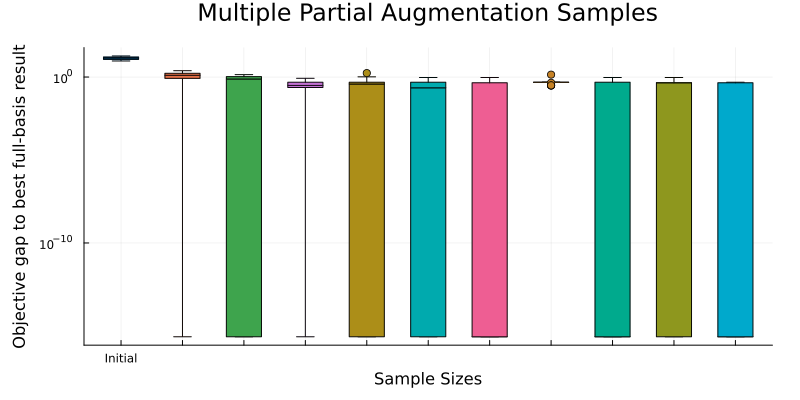

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ER

In [23]:
"""Plot the log-scaled objective gap to the best full-basis result across sample sizes."""
function plot_multiple_partial_augmentation(Y_feas, Y_mpaug, global_minimum)
    Y = hcat(Y_feas, Y_mpaug')
    Y_gap = max.(Y .- global_minimum, eps(Float64))
    X = permutedims(["Initial"; ["\$ $(10i) %|G| \$" for i = 1:size(Y_mpaug, 1)]])

    plt = boxplot(X, Y_gap;
        plot_title = "Multiple Partial Augmentation Samples",
        size       = (800, 400),
        margin     = 5mm,
        ylabel     = "Objective gap to best full-basis result",
        xlabel     = "Sample Sizes",
        yscale     = :log10,
        legend     = false,
    )

    return plt
end

plot_multiple_partial_augmentation(Y_feas, Y_mpaug, minimum(Y_aug))


### References

<a id="reference-1"></a>- [1] M. Alghassi, S. Dridi, and M. Tayur, [arXiv:1902.04215](https://arxiv.org/abs/1902.04215)
<a id="reference-2"></a>- [2] M. Alghassi, S. Dridi, and M. Tayur, [arXiv:1907.10930](https://arxiv.org/abs/1907.10930)
<a id="reference-3"></a>- [3] [QuIPML22](https://github.com/bernalde/QuIPML22/)
